# L1 and L2 norm visualization

## 1D

In [1]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import scipy

In [2]:
def f(x):
    return 0.1 * (x - 5) ** 2 + 2

def l1norm(x):
    return np.abs(x)

def l2norm(x):
    return x ** 2

In [3]:
def plot2d(x, loss, regterm, regloss, title=''):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(x, loss, color='red', alpha=0.6, label='org. loss')
    ax.plot(x, regterm, color='green', alpha=0.8, label='reg. term')
    ax.plot(x, regloss, color='brown', alpha=1, label='reg. loss')
    ax.set_aspect(aspect='equal')
    plt.grid()
    plt.legend()
    plt.title(title)
    plt.show()

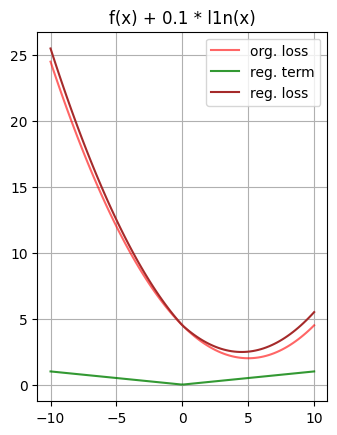

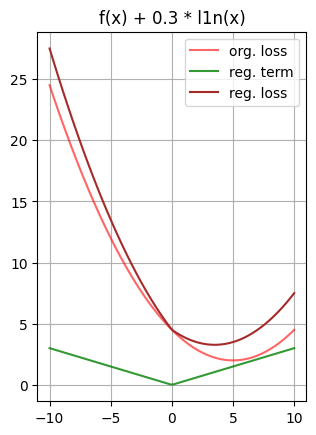

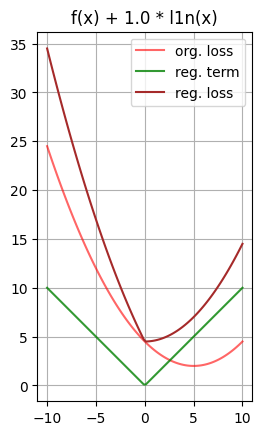

In [4]:
# L1 norm

x = np.linspace(start=-10, stop=10, num=100)

for gamma in (0.1, 0.3, 1.):
    loss = f(x)
    regterm = gamma * l1norm(x)
    regloss = loss + regterm
    plot2d(x, loss, regterm, regloss, f'f(x) + {gamma} * l1n(x)')

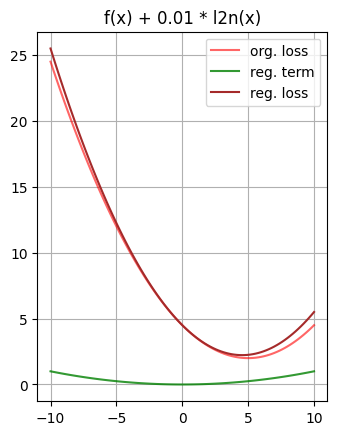

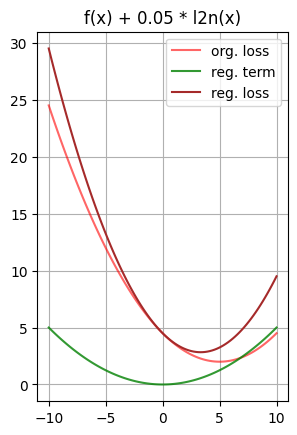

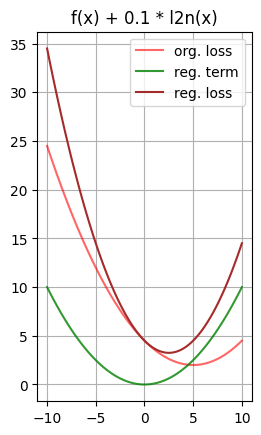

In [5]:
# L2 norm

x = np.linspace(start=-10, stop=10, num=100)

for gamma in (0.01, 0.05, 0.1):
    loss = f(x)
    regterm = gamma * l2norm(x)
    regloss = loss + regterm
    plot2d(x, loss, regterm, regloss, f'f(x) + {gamma} * l2n(x)')

## 2D

In [6]:
def ff(xx, mu=np.array([[0.,0.]]), sigma=np.array([[1.,0.], [0.,1.]])):
    xx = xx - mu
    zz = np.matmul(xx, sigma)
    zz = zz * xx
    zz = zz[:, 0] + zz[:, 1]
    dim = int(np.sqrt(xx.shape[0]))
    return zz.reshape((dim, dim))

def l1norm(x1, x2):
    return np.abs(x1) + np.abs(x2)

def l2norm(x1, x2):
    return x1 ** 2 + x2 ** 2

In [7]:
def plot3d(x1, x2, loss, regterm, regloss):
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
    surf = ax.plot_surface(x1, x2, regloss,
                           cmap=cm.RdBu_r,
                           linewidth=2, alpha=0.3,
                           antialiased=False)
    contour = ax.contour(x1, x2, regloss, cmap=cm.coolwarm,
                         zdir='z', levels=20, offset=-2)
    plt.grid(True)
    plt.tight_layout()
    plt.title('reg. loss')
    plt.show()

    fig, ax = plt.subplots()
    plt.contourf(x1, x2, loss, cmap=cm.RdBu_r,
                 levels=20, alpha=0.8, antialiased=False)
    ax.set_aspect(aspect='equal')
    plt.grid(True)
    plt.tight_layout()
    plt.title('org. loss')
    plt.show()

    fig, ax = plt.subplots()
    plt.contourf(x1, x2, regterm, cmap=cm.RdBu_r,
                 levels=20, alpha=0.8, antialiased=False)
    ax.set_aspect(aspect='equal')
    plt.grid(True)
    plt.tight_layout()
    plt.title('reg. term')
    plt.show()

    fig, ax = plt.subplots()
    plt.contourf(x1, x2, regloss, cmap=cm.RdBu_r,
                 levels=20, alpha=0.8, antialiased=False)
    ax.set_aspect(aspect='equal')
    plt.grid(True)
    plt.tight_layout()
    plt.title('reg. loss')
    plt.show()

In [8]:
x1 = np.linspace(start=-2, stop=10, num=1200)
x2 = np.linspace(start=-2, stop=10, num=1200)
x1, x2 = np.meshgrid(x1, x2)
xx = np.stack((x1.flatten(), x2.flatten()), axis=1)

mu = np.array([[4., 4.]])

sigma1 = np.array([[1.,   0.],
                   [0.,   1.]])

sigma2 = np.array([[2.,   0.],
                   [0.,   1.]])

sigma3 = np.array([[2.,   0.8],
                   [0.5,  1. ]])

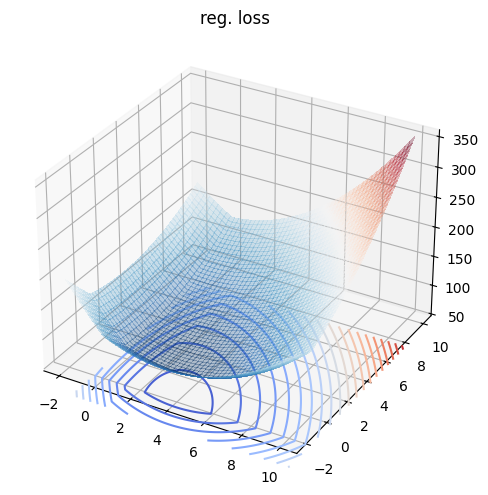

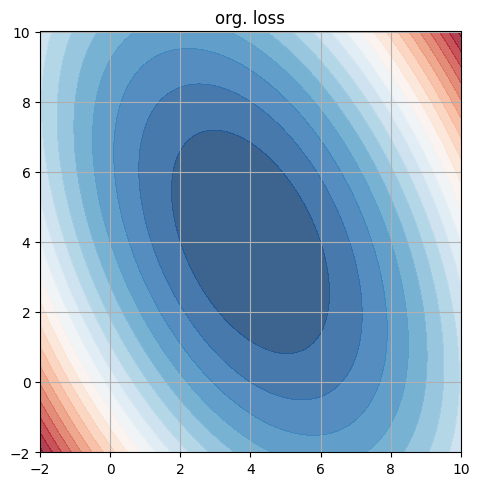

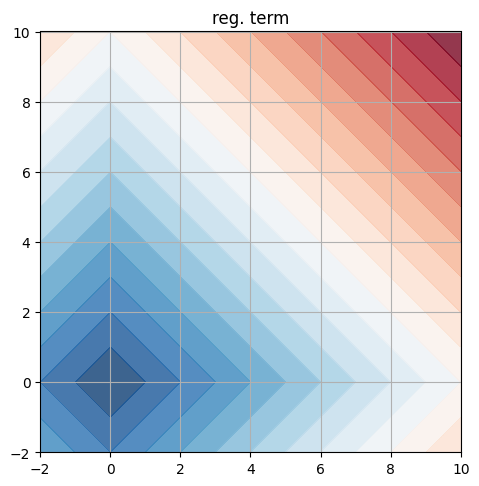

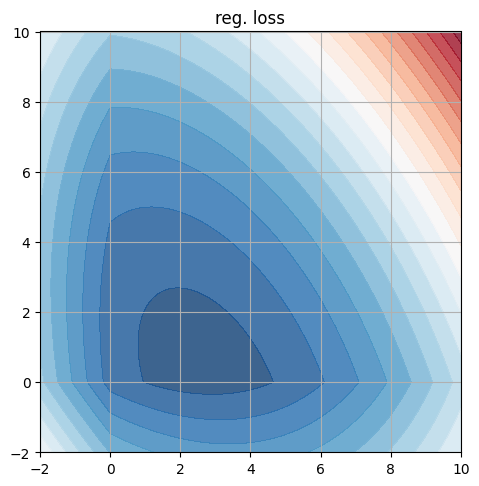

In [9]:
loss = ff(xx, mu, sigma3)
regterm = l1norm(x1, x2)
regloss = loss + 10 * regterm
plot3d(x1, x2, loss, regterm, regloss)

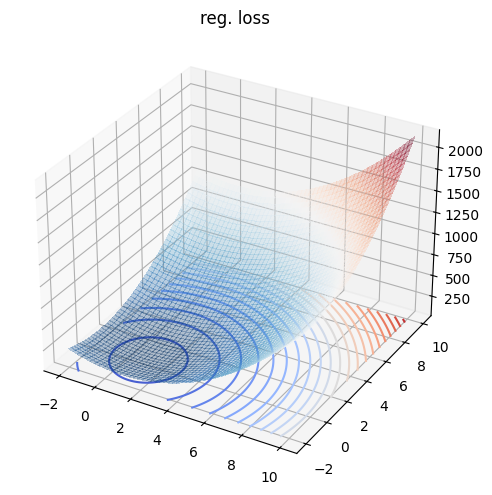

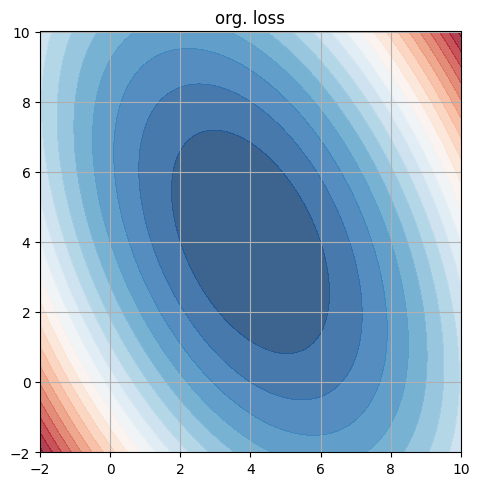

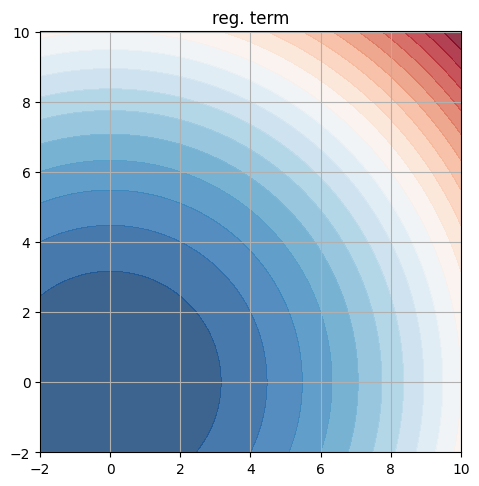

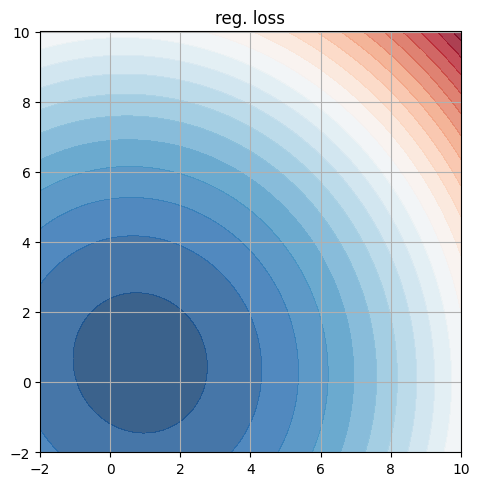

In [10]:
loss = ff(xx, mu, sigma3)
regterm = l2norm(x1, x2)
regloss = loss + 10 * regterm
plot3d(x1, x2, loss, regterm, regloss)